In [1]:
! pip install transformers lime shap 
! pip install tree_sitter tree_sitter_go tree_sitter_java tree_sitter_javascript tree_sitter_php tree_sitter_python tree_sitter_ruby


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
MODEL_PATH = "huggingface/CodeBERTa-language-id"
LIME_SAMPLES = 100

In [3]:
# Loading the model and tokenizer
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification, TextClassificationPipeline

model = RobertaForSequenceClassification.from_pretrained(MODEL_PATH, output_attentions=True)
tokenizer = RobertaTokenizerFast.from_pretrained(MODEL_PATH)

pipeline = TextClassificationPipeline(
    model=model,
    tokenizer=tokenizer,
    top_k=None
)

Some weights of the model checkpoint at huggingface/CodeBERTa-language-id were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


In [4]:
inputs_to_explain = ["def ciao():\n\tend = idk() + random + \"return_\"\n\treturn", "secondo esempio a caso"]

In [5]:
# Base model output
model_output = pipeline(inputs_to_explain)
print(model_output)
class_names = [x["label"] for x in model_output[0]]
class_names.sort()
# print(f"{class_names=}")

RobertaSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


[[{'label': 'python', 'score': 0.8958556652069092}, {'label': 'ruby', 'score': 0.08590037375688553}, {'label': 'javascript', 'score': 0.01670524850487709}, {'label': 'java', 'score': 0.0013597395736724138}, {'label': 'go', 'score': 0.00015211646677926183}, {'label': 'php', 'score': 2.6897667339653708e-05}], [{'label': 'java', 'score': 0.42197155952453613}, {'label': 'ruby', 'score': 0.2658812701702118}, {'label': 'python', 'score': 0.2546652555465698}, {'label': 'javascript', 'score': 0.05144217610359192}, {'label': 'go', 'score': 0.00551580497995019}, {'label': 'php', 'score': 0.0005239781457930803}]]


In [ ]:
# LIME
from lime.lime_text import LimeTextExplainer
import torch
class LIME_predictor():
    def __init__(self, model, tokenizer):
        self.model=model
        self.tokenizer=tokenizer
        
    def prediction(self, texts):
        outputs = self.model(**self.tokenizer(texts, return_tensors="pt", padding=True))
        tensor_logits = outputs[0]
        probabilities = torch.nn.functional.softmax(tensor_logits, dim=1).detach().numpy()
        return probabilities

def LIME_explain_single(explainer, input_string, pipeline, num_features=15, num_samples=LIME_SAMPLES, top_labels=1):
    results = explainer.explain_instance(input_string, pipeline, num_features=num_features, num_samples=num_samples, top_labels=top_labels)
    results.show_in_notebook(text=input_string)
    
    return results.as_list(label=results.top_labels[0])
    

lime_explainer = LimeTextExplainer(class_names=class_names)
lime_words = []
predictor = LIME_predictor(model, tokenizer)
for input_string in inputs_to_explain:
    lime_words.append(LIME_explain_single(lime_explainer, input_string, predictor.prediction))
[print(f"Important words for input {i}: ",x) for i,x in enumerate(lime_words)]

Important words for input 0:  [(np.str_('def'), 0.3773202842685347), (np.str_('ciao'), 0.27605693642001006), (np.str_('random'), 0.2480256869934221), (np.str_('end'), -0.16183666711311928), (np.str_('return_'), 0.13316380810775386), (np.str_('idk'), 0.062025822267544224), (np.str_('return'), 0.024855640061044834)]
Important words for input 1:  [(np.str_('esempio'), 0.30223168574524845), (np.str_('secondo'), -0.22719161159456072), (np.str_('a'), -0.19521624485420713), (np.str_('caso'), -0.13336057271193524)]


[None, None]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 3it [00:37, 18.57s/it]               


go feature importance


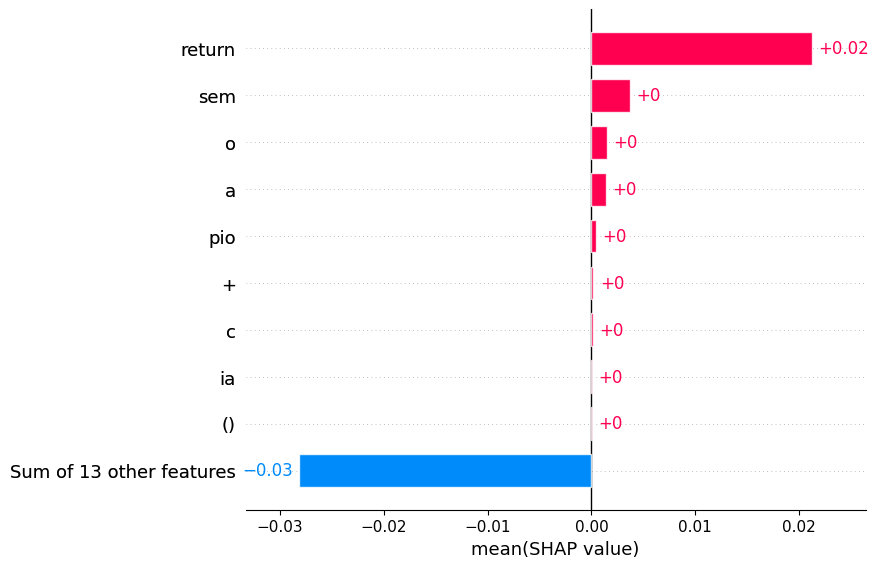

java feature importance


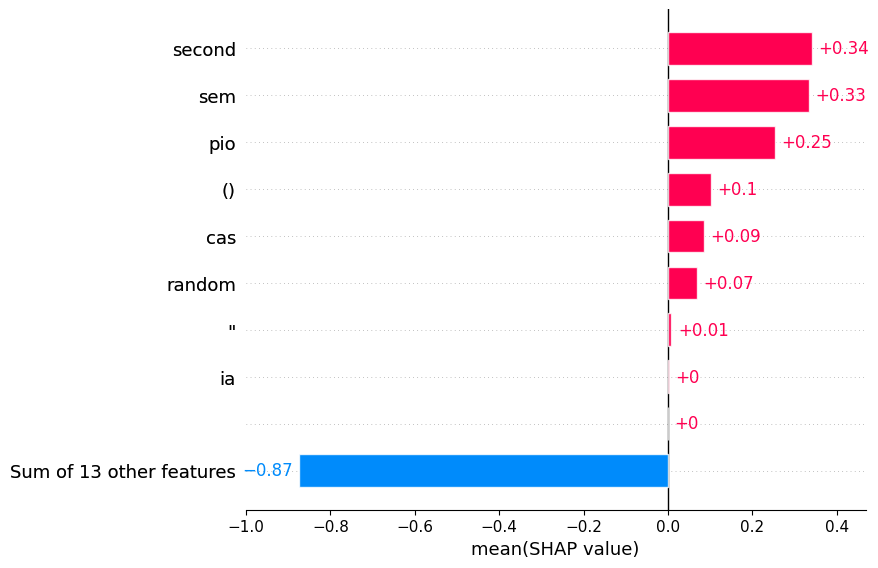

javascript feature importance


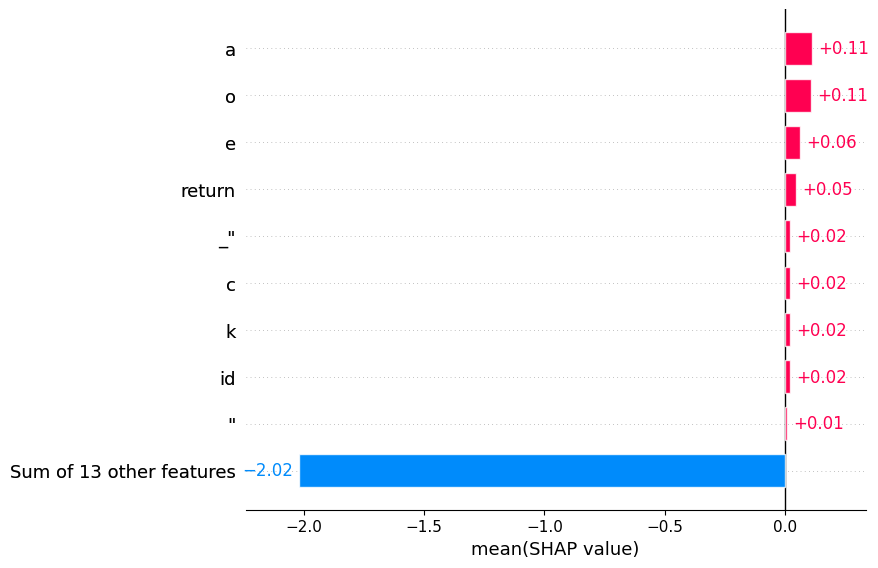

php feature importance


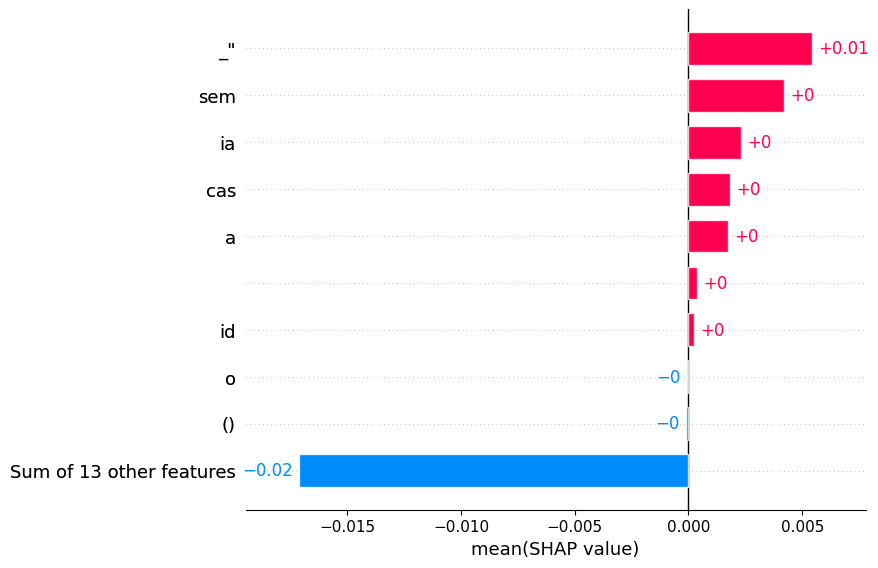

python feature importance


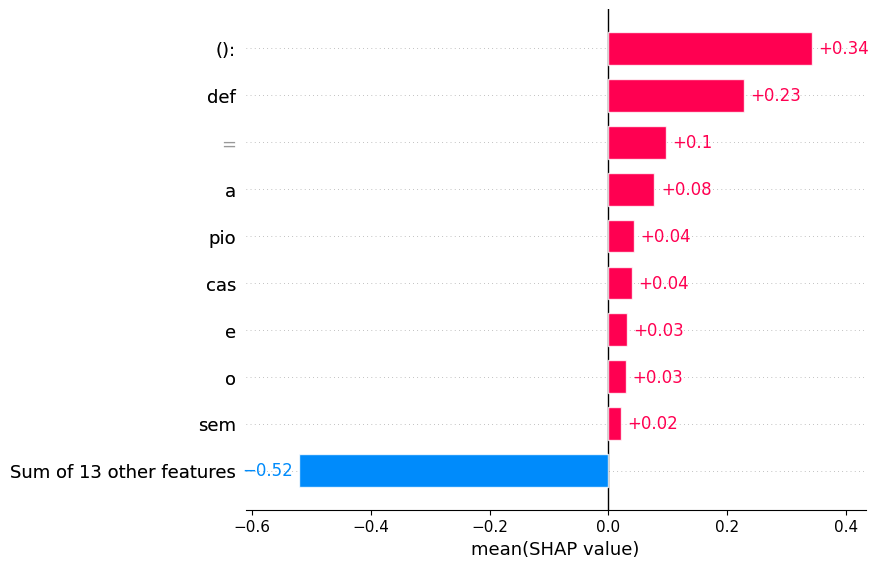

ruby feature importance


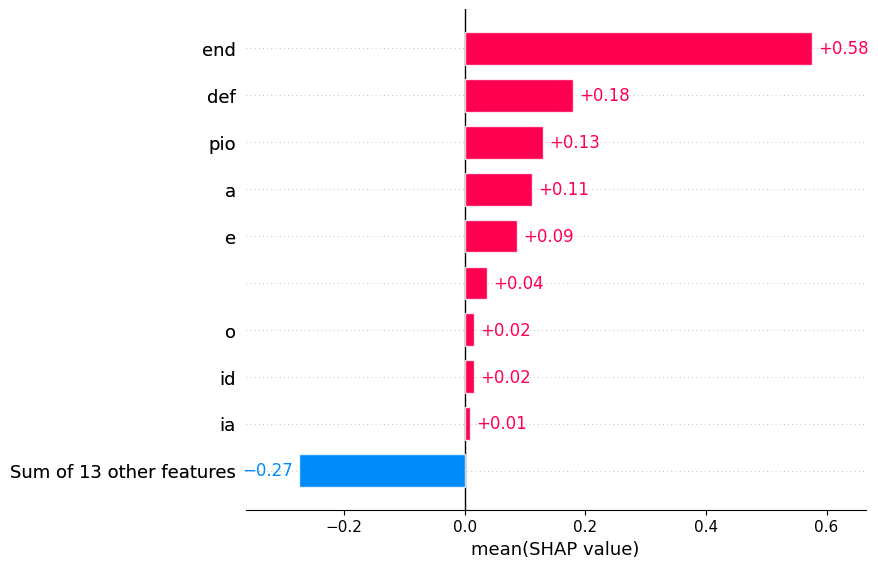

In [7]:
# SHAP
import shap

explainer = shap.Explainer(pipeline)
shap_values = explainer(inputs_to_explain)
shap.plots.text(shap_values)
if len(shap_values)>1:
    for i,l in enumerate(class_names):
        print(f"{l} feature importance")
        shap.plots.bar(shap_values[:,:,i].mean(0), order=shap.Explanation.argsort.flip)

In [8]:
# Preprocessing shap values to represent correctly words
import numpy as np

# print(shap_values[0])
new_values = np.empty(shap_values.shape[0], dtype=object)
new_base_values = np.empty(shap_values.shape[0], dtype=object)
new_data = np.empty(shap_values.shape[0], dtype=object)
for i, x in enumerate(inputs_to_explain):
    tokens = tokenizer(x)
    word_ids = tokens.word_ids()
    print(word_ids[-2])
    tmp_data = np.empty(word_ids[-2]+1, dtype=object)
    tmp_values = np.zeros((word_ids[-2]+1, len(class_names)), dtype=np.float64)
    tmp_id = 0
    string = ""
    for index, id in enumerate(word_ids):
        if id is not None:
            if id != tmp_id:
                tmp_data[tmp_id] = string
                string = ""
                tmp_id = id
            string += shap_values[i].data[index]
            tmp_values[id] = np.sum([tmp_values[id], shap_values[i].values[index]], axis=0)
    tmp_data[-1] = string
    print(tmp_values.shape)
    new_values[i] = tmp_values
    new_base_values[i] = shap_values[i].base_values
    new_data[i] = tmp_data

new_shap_values = shap.Explanation(new_values, base_values=new_base_values, data=new_data, output_names=class_names, clustering=shap_values.clustering)
print(new_shap_values.shape, shap_values.shape)


17
(18, 6)
3
(4, 6)
(2, None, 6) (2, None, 6)


In [11]:
shap.plots.text(new_shap_values)
print(shap_values.clustering)
print(new_shap_values.hierarchical_values)
if len(shap_values)>1:
    for i,l in enumerate(class_names):
        print(f"{l} feature importance")
        shap.plots.bar(new_shap_values[:,:,i].mean(0), order=shap.Explanation.argsort.flip)

[array([[ 2.        ,  3.        ,  0.08695652,  2.        ],
        [10.        , 11.        ,  0.08695652,  2.        ],
        [23.        ,  4.        ,  0.13043478,  3.        ],
        [ 0.        ,  1.        ,  0.08695652,  2.        ],
        [ 5.        ,  6.        ,  0.08695652,  2.        ],
        [ 7.        ,  8.        ,  0.08695652,  2.        ],
        [12.        , 13.        ,  0.08695652,  2.        ],
        [14.        , 15.        ,  0.08695652,  2.        ],
        [16.        , 17.        ,  0.08695652,  2.        ],
        [18.        , 19.        ,  0.08695652,  2.        ],
        [20.        , 21.        ,  0.08695652,  2.        ],
        [28.        ,  9.        ,  0.13043478,  3.        ],
        [33.        , 22.        ,  0.13043478,  3.        ],
        [24.        , 29.        ,  0.17391304,  4.        ],
        [30.        , 31.        ,  0.17391304,  4.        ],
        [26.        , 25.        ,  0.2173913 ,  5.        ],
        

ValueError: operands could not be broadcast together with shapes (18,) (4,) 

In [ ]:
pip install numpy


Note: you may need to restart the kernel to use updated packages.
